In [1]:
from pathlib import Path
import sys

# Add the parent directory to the path
sys.path.append(str(Path().resolve().parent))

from circleplots import plot_circle
from circleplots import plot_circle_2

from circleplots import plot_circle_2_subplots

from importlib import reload

In [2]:
import matplotlib.pyplot as plt

# Normal chirality

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


n = (theta, phi) = (90.0, 20.0)


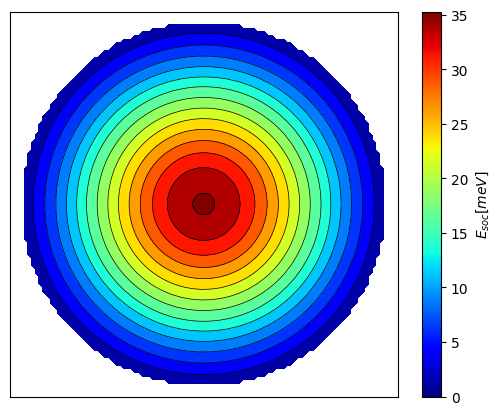

In [3]:
plot_circle('SOC_circle_normal.npz',name='MnTe2_circle.pdf', save=False)

# Opposite chirality

In [4]:
import numpy as np
test = np.load('SOC_circle_opposite.npz')

n = (theta, phi) = (180.0, 0.0)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


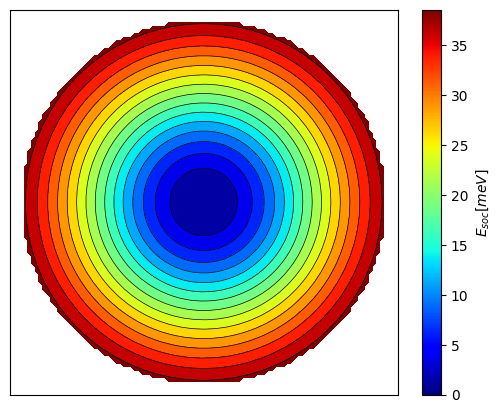

In [5]:
plot_circle('SOC_circle_opposite.npz',name='test_2', save=False)

# Finding difference

Plotting absolute energy scales

Note: the original non-SOC calculation was based on a CW spiral (or, normal vector in the -z direction).
The circle plots will always find the minimum to align with the spin-spiral normal vector!
Therefore, in the plots below, it will be smallest in the -z direction.

Had we run a CCW spiral (or, normal vector in the z-direction), it would have been flipped colors.

In [6]:
# First, load both datasets and find the global minimum
upper = np.load('SOC_circle_normal.npz') #Upper hemisphere
lower = np.load('SOC_circle_opposite.npz') #Lower hemisphere


global_emin = min(np.min(upper['soc']), np.min(lower['soc']))
global_emax_mev = max(np.max(upper['soc']) - global_emin,
                      np.max(lower['soc']) - global_emin) * 1e3

In [7]:
# # #uncomment when latex plot is desired
# from matplotlib import rc
# rc('text', usetex=True) 
# rc('font', family='serif')

/home/runeekman/Desktop/DFT-project-2026/circleplots.py:367: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


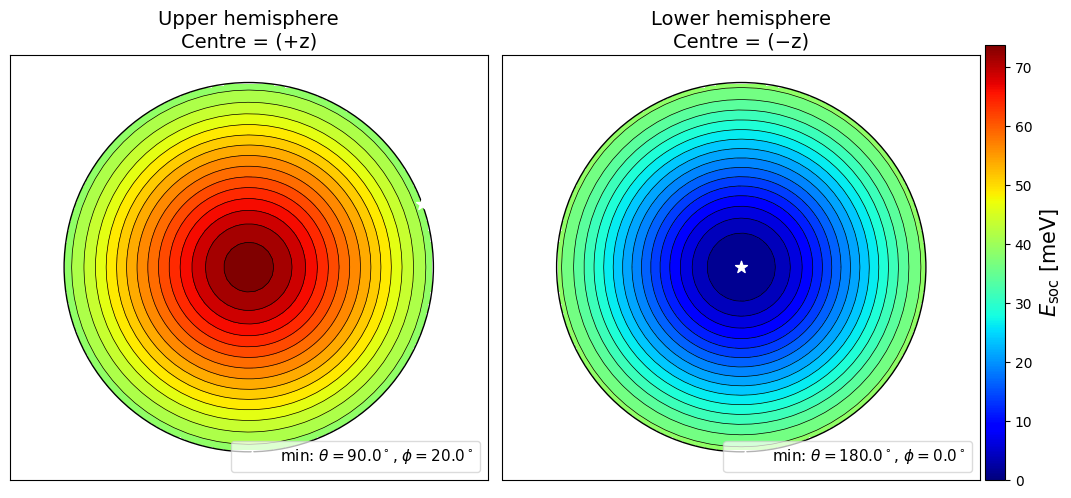

(<Figure size 1000x500 with 3 Axes>,
 (<Axes: title={'center': 'Upper hemisphere\nCentre = (+z)'}>,
  <Axes: title={'center': 'Lower hemisphere\nCentre = (−z)'}>))

In [8]:
import circleplots
reload(circleplots)

circleplots.plot_circle_2_subplots(
    'SOC_circle_normal.npz',
    'SOC_circle_opposite.npz',
    name='MnTe2_combined_soc_plots.pdf',
    global_emin=global_emin,  # or set to a common reference
    global_emax=global_emax_mev     # or set to a common max for both
)

# Flipping colors

In [42]:
import numpy as np                                                                                                      
from gpaw.occupations import create_occ_calc                                                                            
from gpaw.spinorbit import soc_eigenstates                                                                              
from gpaw.new.ase_interface import GPAW
import math
import warnings

from matplotlib.colors import Normalize
from matplotlib import pyplot as plt
from scipy.interpolate import griddata

def sphere_points(distance=None):                                                                                       
    '''Calculates equidistant points on the upper half sphere                                                           
                                                                                                                        
    Returns list of spherical coordinates (thetas, phis) in degrees                                                     
                                                                                                                        
    Modified from:                                                                                                      
        M. Deserno 2004 If Polymerforshung (Ed.) 2 99                                                                   
    '''                                                                                                                 
                                                                                                                        
    N = math.ceil(129600 / (math.pi) * 1 / distance**2)                                                                 
    if N <= 1:                                                                                                          
        return np.array([0.]), np.array([0.])                                                                           
                                                                                                                        
    A = 4 * math.pi                                                                                                     
    a = A / N                                                                                                           
    d = math.sqrt(a)                                                                                                    
                                                                                                                        
    # Even number of theta angles ensure 90 deg is included                                                             
    Mtheta = round(math.pi / (2 * d)) * 2                                                                               
    dtheta = math.pi / Mtheta                                                                                           
    dphi = a / dtheta                                                                                                   
    points = []                                                                                                         
                                                                                                                        
    # Limit theta loop to upper half-sphere                                                                             
    for m in range(Mtheta // 2 + 1):                                                                                    
        # m = 0 ensure 0 deg is included, Mphi = 1 is used in this case                                                 
        theta = math.pi * m / Mtheta                                                                                    
        Mphi = max(round(2 * math.pi * math.sin(theta) / dphi), 1)                                                      
        for n in range(Mphi):                                                                                           
            phi = 2 * math.pi * n / Mphi                                                                                
            points.append([theta, phi])                                                                                 
    thetas, phis = np.array(points).T                                                                                   
                                                                                                                        
    if not any(thetas - np.pi / 2 < 1e-14):                                                                             
        warnings.warn('xy-plane not included in sampling')                                                              
                                                                                                                        
    return thetas * 180 / math.pi, phis * 180 / math.pi   



def sphere_points_lower(distance=None):
    '''Calculates equidistant points on the lower half sphere,
    corresponding to opposite chirality spin spiral configurations.

    Returns list of spherical coordinates (thetas, phis) in degrees.
    Mirrors sphere_points() by reflecting theta -> 180 - theta.
    '''
    thetas, phis = sphere_points(distance=distance)
    return 180.0 - thetas, phis
                                                


def stereo_project_point(inpoint, axis=0, r=1):   
    """
    For axis=2 and r=+1: projects from the south pole (0,0,-1),
        mapping the north pole to the origin and the equator to the unit circle.
        Use for upper hemisphere data (theta in [0, 90]).

    For axis=2 and r=-1: projects from the north pole (0,0,+1),
        mapping the south pole to the origin and the equator to the unit circle.
        Use for lower hemisphere data (theta in [90, 180]).

    In both cases, the relevant pole maps to the centre of the disk
    and the equator maps to the unit circle — so both plots fill a
    unit disk and are directly visually comparable in layout.
    """                                                                      
    point = np.divide(inpoint * r, inpoint[axis] + r)                                                                   
    point[axis] = 0                                                                                                     
    return point          



def plot_circle(socdata, name='SOC_plot',save=True,):                                                                                                    
    
    # Load data from nii2_soc.py                                                                                            
    data = np.load(socdata)                                                                                          
    theta, phi = data['theta'], data['phi']                                                                                 
    soc = (data['soc'] - min(data['soc'])) * 10**3                                                                          
                                                                                                                            
    # Convert angles to xyz coordinates                                                                                     
    theta = theta * np.pi / 180                                                                                             
    phi = phi * np.pi / 180                                                                                                 
    x = np.sin(theta) * np.cos(phi)                                                                                         
    y = np.sin(theta) * np.sin(phi)                                                                                         
    z = np.cos(theta)                                                                                                       
    points = np.array([x, y, z]).T           

    # Detect hemisphere and set projection pole accordingly:
    #   upper (z >= 0): project from south pole (r=+1, default)
    #   lower (z <= 0): project from north pole (r=-1)
    lower_hemisphere = np.mean(z) < 0
    r = -1 if lower_hemisphere else 1

    projected_points = [stereo_project_point(p, axis=2, r=r) for p in points]

    #PLOT                                                
                                                                                                                            
    fig, ax = plt.subplots(1, 1, figsize=(5 * 1.25, 5))                                                                     
                                                                                                                            
    # Plot contour surface                                                                                                  
    norm = Normalize(vmin=min(soc), vmax=max(soc))                                                                          
    X, Y, Z = np.array(projected_points).T                                                                                  
    xi = np.linspace(min(X), max(X), 100)                                                                                   
    yi = np.linspace(min(Y), max(Y), 100)                                                                                   
    zi = griddata((X, Y), soc, (xi[None, :], yi[:, None]))                                                                  
    ax.contour(xi, yi, zi, 15, linewidths=0.5, colors='k', norm=norm)                                                       
    ax.contourf(xi, yi, zi, 15, cmap=plt.cm.jet, norm=norm)                                                                 
                                                                                                                            
    # Add additional contours                                                                                               
    mask = np.argwhere(soc <= np.min(soc) + 0.05)                                                                           
    #ax.scatter(X[mask], Y[mask], marker='o', c='midnightblue', s=5)                                                        
    mask = np.argwhere(soc <= np.min(soc) + 0.001)                                                                          
    #ax.scatter(X[mask], Y[mask], marker='o', c='k', s=5)                                                                   
    # Spin-orbit energy minimum                                                                                             
    mask = np.argwhere(soc <= np.min(soc))                                                                                  
    #ax.scatter(X[mask], Y[mask], marker='o', c='white', s=5)                                                               
    # z-axis direction                                                                                                      
    #ax.scatter(X[0], Y[0], marker='o', c='k', s=10)                                                                        
                                                                                                                            
    theta_min = round(theta[mask][0][0] * 180 / np.pi, 2)                                                                   
    phi_min = round(phi[mask][0][0] * 180 / np.pi, 2)                                                                       
    print(f'n = (theta, phi) = ({theta_min}, {phi_min})')                                                                   
                                                                                                                            
    # Set plot details                                                                                                      
    ax.axis('equal')                                                                                                        
    ax.set_xlim(-1.05, 1.05)                                                                                                
    ax.set_ylim(-1.05, 1.05)                                                                                                
    ax.set_xticks([])                                                                                                       
    ax.set_yticks([])                                                                                                       
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='jet'), ax=ax)                                                
    cbar.ax.set_ylabel(r'$E_{soc} [meV]$')                                                                                  
                                                                                                                            
    # Save figure   
    if save:
        plt.savefig(name)                                                                                                         
    plt.show()
                                                                                                   


                                  
def plot_circle_2(socdata, name='SOC_plot', save=True, global_emin=None, global_emax=None):
    '''Plot stereographic projection of SOC energy landscape.

    Parameters
    ----------
    socdata : str
        Path to .npz file containing 'theta', 'phi', 'soc' arrays.
    name : str
        Output filename for saved figure.
    save : bool
        Whether to save the figure.
    global_emin : float or None
        If provided, use this as the zero reference (in eV) instead of the
        local minimum. Pass the same value to both hemisphere plots to make
        their colour scales directly comparable.
    global_emax : float or None
        If provided, use this as the colour scale maximum (in meV above
        global_emin). Pass the same value to both plots for comparability.
    '''
    # Load data
    data = np.load(socdata)
    theta_deg = data['theta']
    phi_deg = data['phi']
    soc_ev = data['soc']  # in eV

    # Report absolute energies for cross-plot comparison
    print(f'Absolute SOC energies in {socdata}:')
    print(f'  min = {np.min(soc_ev):.6f} eV')
    print(f'  max = {np.max(soc_ev):.6f} eV')
    print(f'  range = {(np.max(soc_ev) - np.min(soc_ev))*1e3:.4f} meV')

    # Shift to common reference if provided, otherwise use local minimum
    e_ref = global_emin if global_emin is not None else np.min(soc_ev)
    soc = (soc_ev - e_ref) * 1e3  # convert to meV

    # Convert angles to radians and then to Cartesian coordinates
    theta = theta_deg * np.pi / 180
    phi = phi_deg * np.pi / 180
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    points = np.array([x, y, z]).T

    # Detect hemisphere:
    #   upper (mean z >= 0, theta in [0, 90]):  project from south pole (r=+1)
    #   lower (mean z <  0, theta in [90,180]): project from north pole (r=-1)
    # In both cases the respective pole maps to the centre of the disk,
    # and the equator maps to the unit circle rim.
    lower_hemisphere = np.mean(z) < 0
    r = -1 if lower_hemisphere else 1
    label = 'Lower hemisphere (spin-down / opposite chirality)' if lower_hemisphere \
            else 'Upper hemisphere (spin-up / original chirality)'
    print(f'Hemisphere: {label}')

    projected_points = [stereo_project_point(p, axis=2, r=r) for p in points]

    # Energy minimum location
    mask = np.argwhere(soc <= np.min(soc))
    theta_min = round(theta[mask][0][0] * 180 / np.pi, 2)
    phi_min = round(phi[mask][0][0] * 180 / np.pi, 2)
    print(f'SOC minimum at: (theta, phi) = ({theta_min} deg, {phi_min} deg)')
    print(f'SOC minimum energy (relative to reference): {np.min(soc):.4f} meV')

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(5 * 1.25, 5))

    vmin = 0
    vmax = global_emax if global_emax is not None else np.max(soc)
    norm = Normalize(vmin=vmin, vmax=vmax)

    X, Y, Z = np.array(projected_points).T
    xi = np.linspace(-1, 1, 200)
    yi = np.linspace(-1, 1, 200)
    zi = griddata((X, Y), soc, (xi[None, :], yi[:, None]))

    ax.contour(xi, yi, zi, 15, linewidths=0.5, colors='k', norm=norm)
    cf = ax.contourf(xi, yi, zi, 15, cmap=plt.cm.jet, norm=norm)

    # Mark the energy minimum
    mask_plot = np.argwhere(soc <= np.min(soc))
    ax.scatter(X[mask_plot], Y[mask_plot], marker='*', c='white', s=80, zorder=5,
               label=f'min: θ={theta_min}°, φ={phi_min}°')
    ax.legend(loc='lower right', fontsize=7, framealpha=0.7)

    # Draw unit circle boundary
    circle = plt.Circle((0, 0), 1, color='k', fill=False, linewidth=1.0)
    ax.add_patch(circle)

    # Axis labels explaining the projection
    if lower_hemisphere:
        ax.set_title(f'Lower hemisphere\nCentre = spin-down (−z), Rim = equatorial (xy-plane)', fontsize=9)
    else:
        ax.set_title(f'Upper hemisphere\nCentre = spin-up (+z), Rim = equatorial (xy-plane)', fontsize=9)

    ax.axis('equal')
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xticks([])
    ax.set_yticks([])

    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='jet'), ax=ax)
    cbar.ax.set_ylabel(r'$E_\mathrm{soc}$ [meV]')

    if save:
        plt.savefig(name, dpi=150, bbox_inches='tight')
    plt.show()   

    return fig, ax                



def _plot_hemisphere(data, ax, global_emin=None, global_emax=None):
    """Plot a single hemisphere on the provided ax."""
    theta_deg = data['theta']
    phi_deg = data['phi']
    soc_ev = data['soc']  # in eV 

    # Shift to common reference
    e_ref = global_emin if global_emin is not None else np.min(soc_ev)
    soc = (soc_ev - e_ref) * 1e3  # convert to meV

    # Convert angles to radians and then to Cartesian coordinates
    theta = theta_deg * np.pi / 180
    phi = phi_deg * np.pi / 180
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    points = np.array([x, y, z]).T

    # Detect hemisphere
    lower_hemisphere = np.mean(z) < 0 
    r = -1 if lower_hemisphere else 1
    label = 'Lower hemisphere (spin-down / opposite chirality)' if lower_hemisphere \
            else 'Upper hemisphere (spin-up / original chirality)'

    # Project points
    projected_points = [stereo_project_point(p, axis=2, r=r) for p in points]

    # Energy minimum location
    mask = np.argwhere(soc <= np.min(soc))
    theta_min = round(theta[mask][0][0] * 180 / np.pi, 2)
    phi_min = round(phi[mask][0][0] * 180 / np.pi, 2)

    # Set up normalization
    vmin = 0
    vmax = global_emax if global_emax is not None else np.max(soc)
    norm = Normalize(vmin=vmin, vmax=vmax)

    # Interpolate for contour plot
    X, Y, Z = np.array(projected_points).T
    xi = np.linspace(-1, 1, 200)
    yi = np.linspace(-1, 1, 200)
    zi = griddata((X, Y), soc, (xi[None, :], yi[:, None]))

    # Plot contours
    ax.contour(xi, yi, zi, 15, linewidths=0.5, colors='k', norm=norm)
    cf = ax.contourf(xi, yi, zi, 15, cmap=plt.cm.jet, norm=norm)

    # Mark the energy minimum
    mask_plot = np.argwhere(soc <= np.min(soc))
    ax.scatter(X[mask_plot], Y[mask_plot], marker='*', c='white', s=80, zorder=5,
                label=rf'min: $\theta={theta_min}^\circ$, $\phi={phi_min}^\circ$'
               )
    ax.legend(loc='lower right', fontsize=11, framealpha=0.7)

    # Draw unit circle boundary
    circle = plt.Circle((0, 0), 1, color='k', fill=False, linewidth=1.0)
    ax.add_patch(circle)

    # Axis labels
    if lower_hemisphere:
        ax.set_title(f'Upper hemisphere\nCentre = (−z)', fontsize=14)
    else:
        ax.set_title(f'Lower hemisphere\nCentre = (+z)', fontsize=14)

    ax.axis('equal')
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xticks([])
    ax.set_yticks([])

    return norm, vmax


def lol_plot_circle_2_subplots(socdata1, socdata2, name='SOC_subplots', global_emin=None, global_emax=None, save=True):
    """Plot two SOC energy landscapes as subplots with a shared colorbar."""
    data1 = np.load(socdata1)
    data2 = np.load(socdata2)

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # Plot each hemisphere
    norm1, vmax1 = _plot_hemisphere(data1, ax1, global_emin, global_emax)
    norm2, vmax2 = _plot_hemisphere(data2, ax2, global_emin, global_emax)

    # Use the maximum vmax for the colorbar
    vmax = max(vmax1, vmax2)
    norm = Normalize(vmin=0, vmax=vmax)

    # Add a single colorbar for both subplots
    #cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='jet'), ax=[ax1, ax2], orientation='vertical', pad=0.02)
    
    cbar_ax = fig.add_axes([0.99, 0.03, 0.02, 0.87])  # [left, bottom, width, height]
    
    cbar = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap='jet'),
    cax=cbar_ax,
    orientation='vertical',
    # fraction=0.02,
    # pad=0.02,
    )
    
    cbar.ax.set_ylabel(r'$E_\mathrm{soc}$ [meV]', fontsize=15)

    plt.tight_layout()
    if save:
        plt.savefig(name, dpi=150, bbox_inches='tight')
    plt.show()
    return fig, (ax1, ax2)

In [43]:
# First, load both datasets and find the global minimum
upper = np.load('SOC_circle_normal.npz') #Upper hemisphere
lower = np.load('SOC_circle_opposite.npz') #Lower hemisphere


global_emin = min(np.min(upper['soc']), np.min(lower['soc']))
global_emax_mev = max(np.max(upper['soc']) - global_emin,
                      np.max(lower['soc']) - global_emin) * 1e3

In [45]:
# #uncomment when latex plot is desired
from matplotlib import rc
rc('text', usetex=True) 
rc('font', family='serif')

/tmp/ipykernel_21088/3669904323.py:367: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


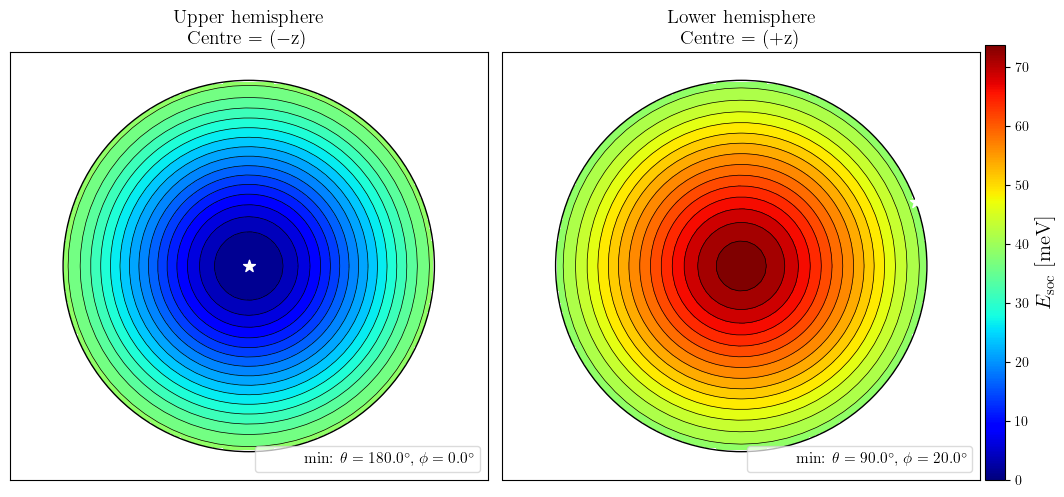

(<Figure size 1000x500 with 3 Axes>,
 (<Axes: title={'center': 'Upper hemisphere\nCentre = (−z)'}>,
  <Axes: title={'center': 'Lower hemisphere\nCentre = (+z)'}>))

In [46]:
lol_plot_circle_2_subplots(
        'SOC_circle_opposite.npz',
    'SOC_circle_normal.npz',
    name='MnTe2_combined_soc_plots.pdf',
    global_emin=global_emin,  # or set to a common reference
    global_emax=global_emax_mev     # or set to a common max for both
)

# With Projected=True

In [ ]:
# upper = np.load('SOC_circle_normal_project_True.npz') #Upper hemisphere
# lower = np.load('SOC_circle_opposite_project_True.npz') #Lower hemisphere

# global_emin = min(np.min(upper['soc']), np.min(lower['soc']))
# global_emax_mev = max(np.max(upper['soc']) - global_emin,
#                       np.max(lower['soc']) - global_emin) * 1e3


# circleplots.plot_circle_2_subplots(
#     'SOC_circle_normal_project_True.npz',
#     'SOC_circle_opposite_project_True.npz',
#     name='MnTe2_combined_soc_plots_project_True.pdf',
#     global_emin=global_emin,  # or set to a common reference
#     global_emax=global_emax_mev,     # or set to a common max for both
#     save=False
# )